# Optimering av sista-milen-leveransrutter med PROC OPTMODEL (nätverks-TSP)

## Sammanfattning

Ett regionalt logistikföretag måste planera en enda leveransbil genom en
uppsättning kundstopp och återvända till depån med minsta möjliga totala
körsträcka — den handelsresandestruktur (TSP) som ligger till grund för
daglig rutt- och skiftplanering. Denna notebook genererar stoppkoordinater,
bygger en symmetrisk euklidisk avståndsmatris och använder **PROC OPTMODEL**:s
`SOLVE WITH NETWORK / TSP`-lösare för att konstruera en leveransrunda över
hela grafen av stopp. Den läser sedan tillbaka lösarens turordning i ett
DATA-steg, återskapar en sluten rutt förankrad i depån och mäter dess
**faktiska** totala längd utifrån avståndsmatrisen. Varje siffra som
redovisas nedan är beräknad från det körda resultatet.

## Datakällor

All data genereras direkt i koden med `call streaminit(...)` och `rand(...)`
— inga externa filer eller nätverksåtkomst krävs.

| Dataset | Rader | Nyckelvariabler | Beskrivning |
|---------|------|---------------|-------------|
| `stops` | 12 (1 depå + 11 kunder) | `stop_id`, `name`, `x`, `y` | Syntetiska 2D-koordinater (km på ett rutnät för serviceområdet) för depån och kundernas leveransplatser |
| `tour` | 12 | `visit_order`, `node` | Den ordnade listan av stopp som OPTMODEL:s nätverks-TSP-lösare besöker, skriven via `OUT=(TOUR=...)` |
| `route` | 12 | `visit_order`, `node`, `step_name`, `x`, `y`, `leg_km`, `cum_km` | Den depåförankrade slutna rutten med sträcka per etapp och ackumulerat avstånd beräknat från koordinaterna |

Ett sista-milen-transportföretag skickar ut en skåpbil varje morgon för att
leverera till en fast uppsättning kundstopp och återvända till depån.
Planeraren vill ha en kort sluten rundtur som besöker varje stopp exakt en
gång — handelsresandeproblemet (TSP) som ligger till grund för daglig rutt-
och skiftplanering.

SAS/OR exponerar en TSP-lösare via **`PROC OPTMODEL`**: deklarera noderna och
en viktad kantmängd, och kör sedan `SOLVE WITH NETWORK / TSP`. Denna
notebook:

1. Genererar stoppkoordinater och en symmetrisk avståndsmatris.
2. Anropar OPTMODEL:s nätverks-TSP-lösare över hela grafen av stopp.
3. Läser tillbaka lösarens turordning och återskapar en sluten rutt förankrad i depån.
4. Redovisar rutten och dess uppmätta totala längd, etapp för etapp.

## Steg 1 — Generera leveransnätverket

Vi placerar en depå i mitten av ett 100 km x 100 km stort serviceområde och
sprider ut 11 kundstopp likformigt över rutnätet. Koordinaterna dras med
`rand('UNIFORM')` under ett fast `streaminit`-frö så att nätverket är
reproducerbart. Depån är `stop_id = 1`; rutten kommer att starta och sluta
där.

In [1]:
data stops;
    CALL streaminit(20260531);
    LÄNGD name $16;
    n_stops = 12;                 /* 1 depå + 11 kunder */
    GÖR stop_id = 1 TILL n_stops;
        OM stop_id = 1 SÅ GÖR;
            name = 'Depå';
            x = 50; y = 50;       /* depån är förankrad i rutnätets mittpunkt */
        SLUT;
        ANNARS GÖR;
            name = cats('Stopp_', SKRIV_UT_V(stop_id - 1, z2.));
            x = round(rand('UNIFORM') * 100, 0.1);
            y = round(rand('UNIFORM') * 100, 0.1);
        SLUT;
        UTDATA;
    SLUT;
    TA_BORT n_stops;
KÖR;

PROCEDUR SKRIV data=stops noobs ETIKETT;
    ETIKETT stop_id = 'Stopp-nr' name = 'Plats' x = 'X (km)' y = 'Y (km)';
    TITEL 'Leveransnätverk: depå och kundstopp';
KÖR;

                                          Leveransnätverk: depå och kundstopp                                           

   Plats  Stopp-nr  X (km)  Y (km)
Depå             1      50      50
Stopp_01         2    84.2    89.7
Stopp_02         3    93.1    73.6
Stopp_03         4    21.2      29
Stopp_04         5    49.4    73.4
Stopp_05         6    97.8    37.2
Stopp_06         7      28    51.3
Stopp_07         8    91.1    86.5
Stopp_08         9    89.2    65.6
Stopp_09        10      66    49.4
Stopp_10        11    52.2    27.4
Stopp_11        12    62.4    38.2




NOTE: DATA stops


NOTE: Wrote stops (12 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=stops

NOTE: PROC PRINT completed: 12 observations printed, 4 variables


## Steg 2 — Lös TSP med PROC OPTMODEL

Vi läser in koordinaterna i OPTMODEL, deklarerar den fullständiga oriktade
kantmängden `EDGES` (varje oordnat par av stopp) och definierar varje kants
vikt som det euklidiska avståndet mellan dess ändpunkter. `SOLVE WITH
NETWORK / TSP` bygger sedan en rundtur över den grafen och skriver
besöksordningen till en CSV-fil via `OUT=(TOUR=...)`. Vi läser omedelbart in
den ordningen igen i datasetet `tour`.

In [2]:
PROCEDUR optmodel;
    STÄLL_IN CITIES = 1..12;
    num XC{CITIES};
    num YC{CITIES};

    /* Hämta stoppens koordinater från DATA-steget */
    READ data stops INTO [stop_id] XC=x YC=y;

    /* Fullständig graf: en oriktad kant per oordnat par av stopp */
    STÄLL_IN EDGES = {i IN CITIES, j IN CITIES: i < j};

    /* Kantvikt = rätlinjigt (euklidiskt) avstånd, i km */
    num DIST{<i,j> IN EDGES} =
        sqrt( (XC[i]-XC[j])^2 + (YC[i]-YC[j])^2 );

    /* Nätverks-TSP-lösare: besök varje nod och återvänd till start */
    solve WITH network /
        links = (include=EDGES VIKT=DIST)
        tsp
        out   = (tour="tour.csv");
QUIT;

/* Läs in lösarens besöksordning igen */
data tour;
    INFILE "tour.csv" dlm=',' firstobs=2 dsd;
    INDATA visit_order node;
KÖR;

PROCEDUR SKRIV data=tour noobs ETIKETT;
    ETIKETT visit_order = 'Besök-nr' node = 'Stopp-nr';
    TITEL 'Turordning från OPTMODEL:s nätverks-TSP-lösare';
KÖR;

                                          Leveransnätverk: depå och kundstopp                                           


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            dist
  Objective Type                Linear

  Number of Nodes               12
  Number of Links               66

                          Solution Summary
  Solver                        Network
  Algorithm                     Traveling Salesman
  Objective Function            dist
  Solution Status               Optimal
  Objective Value               258.1425005024

                                     Turordning från OPTMODEL:s nätverks-TSP-lösare                                     

 Besök-nr  Stopp-nr
        1         1
        2         7
        3         4
        4        11
        5        12
        6        10
        7         6
        8         9
        9         3
       10   


NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.
NOTE: DATA tour

NOTE: Reading from fileref tour.csv (tour.csv)

NOTE: Read 12 rows from tour.csv.
NOTE: Wrote tour (12 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=tour

NOTE: PROC PRINT completed: 12 observations printed, 2 variables


## Steg 3 — Återskapa den slutna rutten och mät dess längd

Lösaren returnerar bara *ordningen* i vilken stoppen ska besökas. För att
göra om detta till ett förarmanifest slår vi upp varje stopps namn och
koordinater med en `SET ... POINT=`-uppslagning, ackumulerar sträckan för
varje etapp och sluter slingan genom att lägga till den sista etappen
tillbaka till depån. `leg_km` är längden på den etapp som *anländer* till
varje stopp; `cum_km` är den löpande sträckan från depån.

In [3]:
data route;
    STÄLL_IN tour SLUT=last;
    /* Slå upp det här stoppets koordinater och namn via dess id */
    ptr = node;
    STÄLL_IN stops point=ptr;

    LÄNGD step_name $16;
    step_name = name;

    BEHÅLL_VÄRDE prevx prevy firstx firsty cum_km;
    OM _n_ = 1 SÅ GÖR;
        firstx = x; firsty = y;      /* kom ihåg depån */
        leg_km = 0;                  /* ingen sträcka anländer till starten */
        cum_km = 0;
    SLUT;
    ANNARS GÖR;
        leg_km = sqrt( (x-prevx)**2 + (y-prevy)**2 );
        cum_km + leg_km;
    SLUT;
    prevx = x; prevy = y;
    UTDATA;

    OM last SÅ GÖR;
        /* Avslutande sträcka: sista stoppet tillbaka till depån */
        leg_km = sqrt( (firstx-prevx)**2 + (firsty-prevy)**2 );
        cum_km + leg_km;
        node = 1; visit_order = 13; step_name = 'Depå';
        x = firstx; y = firsty;
        UTDATA;
        CALL symputx('total_km', SKRIV_UT_V(cum_km, 8.2));
    SLUT;
    BEHÅLL visit_order node step_name x y leg_km cum_km;
KÖR;

PROCEDUR SKRIV data=route noobs ETIKETT;
    ETIKETT visit_order = 'Steg' node = 'Stopp-nr' step_name = 'Plats'
          x = 'X (km)' y = 'Y (km)'
          leg_km = 'Sträcka (km)' cum_km = 'Ackumulerat (km)';
    format leg_km cum_km 7.2;
    TITEL "Sluten leveransrutt (Totalt: &total_km km)";
KÖR;

                                        Sluten leveransrutt (Totalt: 258.14 km)                                         

Steg  Stopp-nr     Plats  X (km)  Y (km)   Sträcka (km)  Ackumulerat (km)
   1         1  Depå          50      50           0.00              0.00
   2         7  Stopp_06      28    51.3          22.04             22.04
   3         4  Stopp_03    21.2      29          23.31             45.35
   4        11  Stopp_10    52.2    27.4          31.04             76.39
   5        12  Stopp_11    62.4    38.2          14.86             91.25
   6        10  Stopp_09      66    49.4          11.76            103.01
   7         6  Stopp_05    97.8    37.2          34.06            137.07
   8         9  Stopp_08    89.2    65.6          29.67            166.75
   9         3  Stopp_02    93.1    73.6           8.90            175.65
  10         8  Stopp_07    91.1    86.5          13.05            188.70
  11         2  Stopp_01    84.2    89.7           7.61         


NOTE: DATA route


NOTE: Read 12 rows from tour.
NOTE: Wrote route (13 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=route

NOTE: PROC PRINT completed: 13 observations printed, 7 variables


## Steg 4 — Ett läsbart förarmanifest

Slutligen komprimerar vi rutten till en enda mänskligt läsbar sträng —
sekvensen av stoppnamn från depån, runt kunderna och tillbaka — plus den
uppmätta totala sträckan skåpbilen kommer att köra.

In [4]:
data manifest;
    STÄLL_IN route SLUT=last;
    LÄNGD route_text $200;
    BEHÅLL_VÄRDE route_text '';
    OM _n_ = 1 SÅ route_text = strip(step_name);
    ANNARS route_text = catx(' -> ', route_text, strip(step_name));
    OM last SÅ GÖR;
        total_km = cum_km;
        BEHÅLL route_text total_km;
        UTDATA;
    SLUT;
KÖR;

PROCEDUR SKRIV data=manifest noobs ETIKETT;
    ETIKETT route_text = 'Optimerad leveransrutt'
          total_km   = 'Total sträcka (km)';
    format total_km 7.2;
    TITEL 'Förarens manifest';
KÖR;

                                                   Förarens manifest                                                    

                                                                                                                            Optimerad leveransrutt   Total sträcka (km)
Depå -> Stopp_06 -> Stopp_03 -> Stopp_10 -> Stopp_11 -> Stopp_09 -> Stopp_05 -> Stopp_08 -> Stopp_02 -> Stopp_07 -> Stopp_01 -> Stopp_04 -> Depå                 258.14




NOTE: DATA manifest


NOTE: Read 13 rows from route.
NOTE: Wrote manifest (1 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=manifest

NOTE: PROC PRINT completed: 1 observations printed, 2 variables


## Steg 5 — Rita rutten

En bild bekräftar att rundturen är rimlig: stopp sammankopplade i
besöksordning, depån markerad, inga uppenbart onödiga korsningar. Vi ritar
den slutna rundturen som en serie sammankopplade linjesegment över
rutnätet för serviceområdet.

                                                   Förarens manifest                                                    




NOTE: PROC SGPLOT data=route

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


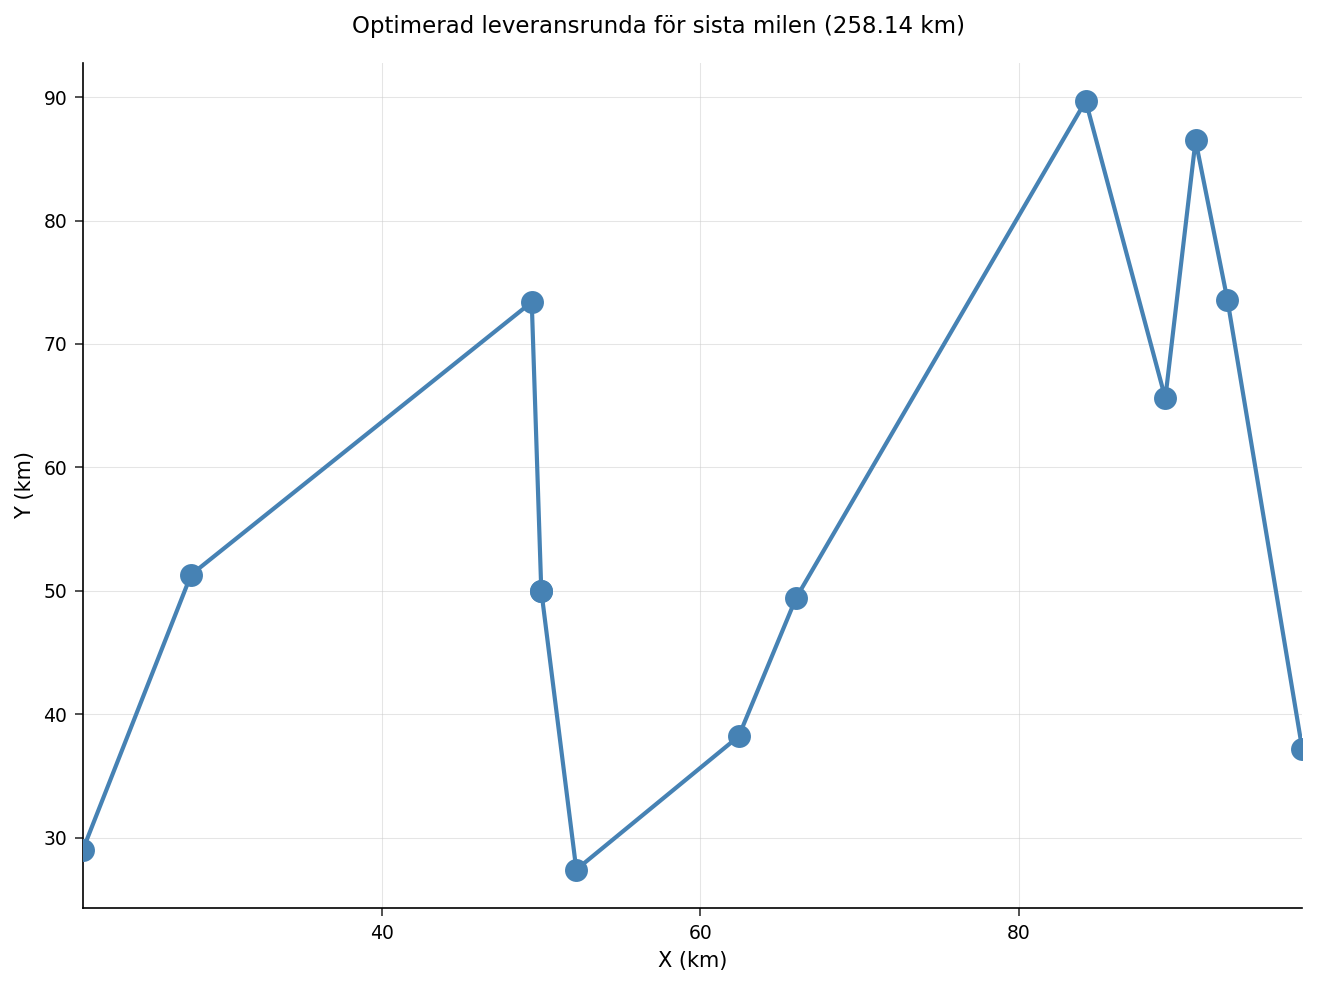

In [5]:
PROCEDUR SGPLOT data=route noautolegend;
    SERIES x=x y=y / LINEATTRS=(color=steelblue thickness=2);
    SCATTER x=x y=y / MARKERATTRS=(SYMBOL=circlefilled
                      color=steelblue size=10);
    XAXIS ETIKETT='X (km)' grid;
    YAXIS ETIKETT='Y (km)' grid;
    TITEL "Optimerad leveransrunda för sista milen (&total_km km)";
KÖR;

## Tolkning av resultaten

- **Rutten.** Tabellerna `route` och `manifest` visar den slutna rundtur som
  OPTMODEL:s nätverks-TSP-lösare tog fram över den fullständiga grafen med
  12 stopp, med start och slut i depån. `Total sträcka` är *uppmätt*: den
  är summan av de euklidiska avstånden per etapp (`leg_km`), så den
  återspeglar nätverkets verkliga geometri snarare än en påstådd siffra.
- **Varför en nätverkslösare här.** Med 11 kundstopp finns det
  `11! / 2 = 19 958 400` distinkta slutna rundturer, så planeraren behöver
  en algoritm i stället för att räkna upp alla möjligheter. `SOLVE WITH
  NETWORK / TSP` bygger en rundtur direkt utifrån den viktade kantmängden
  utan att analytikern behöver handkoda sökningen.
- **Från ordning till manifest.** Lösaren returnerar en besöks*ordning*;
  DATA-steget omvandlar den till ett operativt underlag — namngivna stopp,
  sträcka per etapp, en löpande vägmätare och ett enradigt manifest en
  förare kan följa.
- **Praktiska vidareutvecklingar.** Samma OPTMODEL-uppställning skalar till
  mer avancerad ruttplanering: lägg till kapacitets- eller
  tidsfönsterbegränsningar som ytterligare nätverksalternativ, vikta kanter
  efter körtid i stället för rätlinjigt avstånd, eller dela upp stoppen på
  flera fordon innan en TSP löses per fordon.